# Data Cleaning

Hey Ivette and Julia! As we discussed, I specifically loaded the bank-full.csv file and took the following steps for cleaning:


*   Checked for NA values (there were none to remove)
*   Converted all categorical variables to numeric
*   Defined X_bank_full and y_bank_full as features and target subsets of the bank_full dataframe

I figured for each algorithm I would let each of us do our own training and test set split, unless there's a good reason for us to use the same split. Let me know if I can answer any questions!

-Emmet

In [ ]:
# From: https://archive.ics.uci.edu/dataset/222/bank+marketing
# pip install ucimlrepo

!pip install ucimlrepo

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

# fetch dataset
bank_marketing = fetch_ucirepo(id=222)

# data (as pandas dataframes)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# metadata
print(bank_marketing.metadata)

# variable information
print(bank_marketing.variables)

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

In [ ]:
import pandas as pd

In [ ]:
bank_full = pd.read_csv('/content/drive/MyDrive/Coursework 2025 WIN/IMT 574/Assignments/bank+marketing/bank/bank-full.csv', sep = ';')
print(bank_full.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [ ]:
# Identify unique labels in categorical columns
for column in list(bank_full.columns):
  unique_values= bank_full[str(column)].unique()
  print('Unique values in ' + str(column) + ':' + str(unique_values))

Unique values in age:[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]
Unique values in job:['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Unique values in marital:['married' 'single' 'divorced']
Unique values in education:['tertiary' 'secondary' 'unknown' 'primary']
Unique values in default:['no' 'yes']
Unique values in balance:[ 2143    29     2 ...  8205 14204 16353]
Unique values in housing:['yes' 'no']
Unique values in loan:['no' 'yes']
Unique values in contact:['unknown' 'cellular' 'telephone']
Unique values in day:[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]
Unique values in month:['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr

In [ ]:
# Convert categorical variables with integers
bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
                          'management', 'retired', 'self-employed', 'services',
                          'student', 'technician', 'unemployed', 'unknown'],
                           [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['marital'].replace(['single', 'married', 'divorced'],[1, 2, 3], inplace=True)
bank_full['education'].replace(['tertiary', 'secondary', 'unknown', 'primary'],[3, 2, 0, 1], inplace=True)
bank_full['default'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['housing'].replace(['yes', 'no'], [1, 0], inplace=True)
bank_full['loan'].replace(['no', 'yes'], [0, 1], inplace=True)
bank_full['contact'].replace(['unknown', 'cellular', 'telephone'], [0, 1, 2], inplace=True)
bank_full['month'].replace(['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], inplace=True)
bank_full['poutcome'].replace(['unknown', 'failure', 'other', 'success'], [2, 0, 3, 1], inplace=True)
bank_full['y'].replace(['no', 'yes'], [0, 1], inplace=True)

<ipython-input-7-b8edec95c237>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bank_full['job'].replace(['admin.', 'blue-collar', 'entrepreneur', 'housemaid',
<ipython-input-7-b8edec95c237>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bank_full['job'].replace(['admin.', 'blue-collar', 'entrepre

In [ ]:
# define features and targets dataframes
X_bank_full = bank_full[['age','job','marital','education','default','balance','housing','loan','contact','day','month','duration','campaign','pdays','previous','poutcome']]
y_bank_full = bank_full[['y']]

print(X_bank_full.head())
print(y_bank_full.head())

   age  job  marital  education  default  balance  housing  loan  contact  \
0   58    5        2          3        0     2143        1     0        0   
1   44   10        1          2        0       29        1     0        0   
2   33    3        2          2        0        2        1     1        0   
3   47    2        2          0        0     1506        1     0        0   
4   33   12        1          0        0        1        0     0        0   

   day  month  duration  campaign  pdays  previous  poutcome  
0    5      5       261         1     -1         0         2  
1    5      5       151         1     -1         0         2  
2    5      5        76         1     -1         0         2  
3    5      5        92         1     -1         0         2  
4    5      5       198         1     -1         0         2  
   y
0  0
1  0
2  0
3  0
4  0


# Random Forest Model V2 -- Selected Features

Selected features include:
- duration
- housing
- pdays
- month
- poutcome
- age

In [ ]:
# define features and targets dataframes
X_bank_full_V2 = bank_full[['age','housing','month','duration','pdays','poutcome']]
y_bank_full_V2 = bank_full[['y']]

NameError: name 'bank_full' is not defined

In [ ]:
X_bank_full_V2.head()

,age,housing,month,duration,pdays,poutcome
0,58,1,5,261,-1,2
1,44,1,5,151,-1,2
2,33,1,5,76,-1,2
3,47,1,5,92,-1,2
4,33,0,5,198,-1,2


In [ ]:
# Divide dataset into training and test sets
from sklearn.model_selection import train_test_split
X_train_V2, X_test_V2, y_train_V2, y_test_V2 = train_test_split(X_bank_full_V2, y_bank_full_V2, test_size=0.33, random_state=42, stratify=y)

# Note - I don't know if this is the best split; could try a different method e.g. k-fold, but I'm starting with this

In [ ]:
# Fit random forest model V2
from sklearn.ensemble import RandomForestClassifier
random_forest_model_V2 = RandomForestClassifier(n_estimators = 100, max_depth = 30, min_samples_split=15, criterion = 'entropy', random_state=42)
random_forest_model_V2.fit(X_train_V2, y_train_V2)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(criterion='entropy', max_depth=30, min_samples_split=15,
                       random_state=42)

In [ ]:
# Run predictions for random forest model V2
y_pred_forest_V2 = random_forest_model_V2.predict(X_test_V2)

NameError: name 'random_forest_model_V2' is not defined

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test_V2, y_pred_forest_V2))

NameError: name 'y_test_V2' is not defined

In [ ]:
# View confusion matrix for test data and predictions
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test_V2, y_pred_forest_V2)

array([[12748,   427],
       [ 1002,   743]])

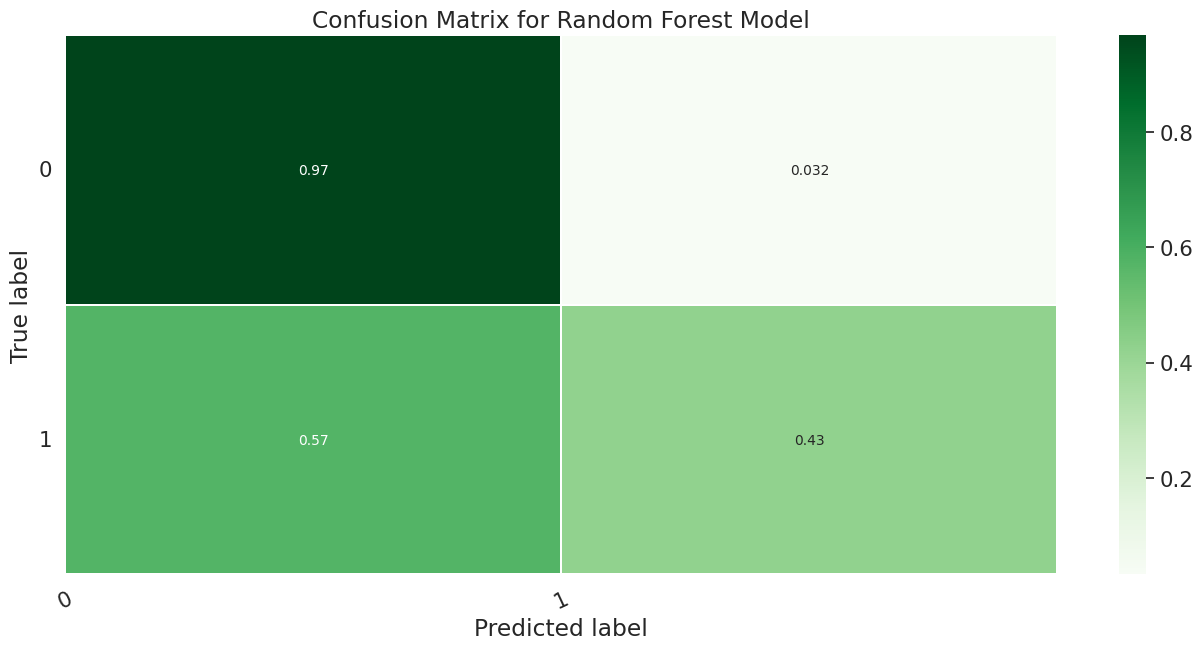

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Get and reshape confusion matrix data
matrix = confusion_matrix(y_test_V2, y_pred_forest_V2)
matrix = matrix.astype('float') / matrix.sum(axis=1)[:, np.newaxis]

# Build the plot
plt.figure(figsize=(16,7))
sns.set(font_scale=1.4)
sns.heatmap(matrix, annot=True, annot_kws={'size':10},
            cmap=plt.cm.Greens, linewidths=0.2)

# Add labels to the plot
class_names = ['0','1']
tick_marks = np.arange(len(class_names))
tick_marks2 = tick_marks + 0.5
plt.xticks(tick_marks, class_names, rotation=25)
plt.yticks(tick_marks2, class_names, rotation=0)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix for Random Forest Model')
plt.show()